In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Class Task  (Modern Matplotlib)

In [12]:
# Task : Temperature data of five cities for five different days are given
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]

cities = ["New York", "London", "Delhi", "Tokyo"]

temperatures = [
    [22, 23, 21, 24, 25],  # New York
    [18, 19, 17, 20, 21],  # London
    [30, 32, 31, 33, 34],  # Delhi
    [25, 26, 24, 27, 28]   # Tokyo
]


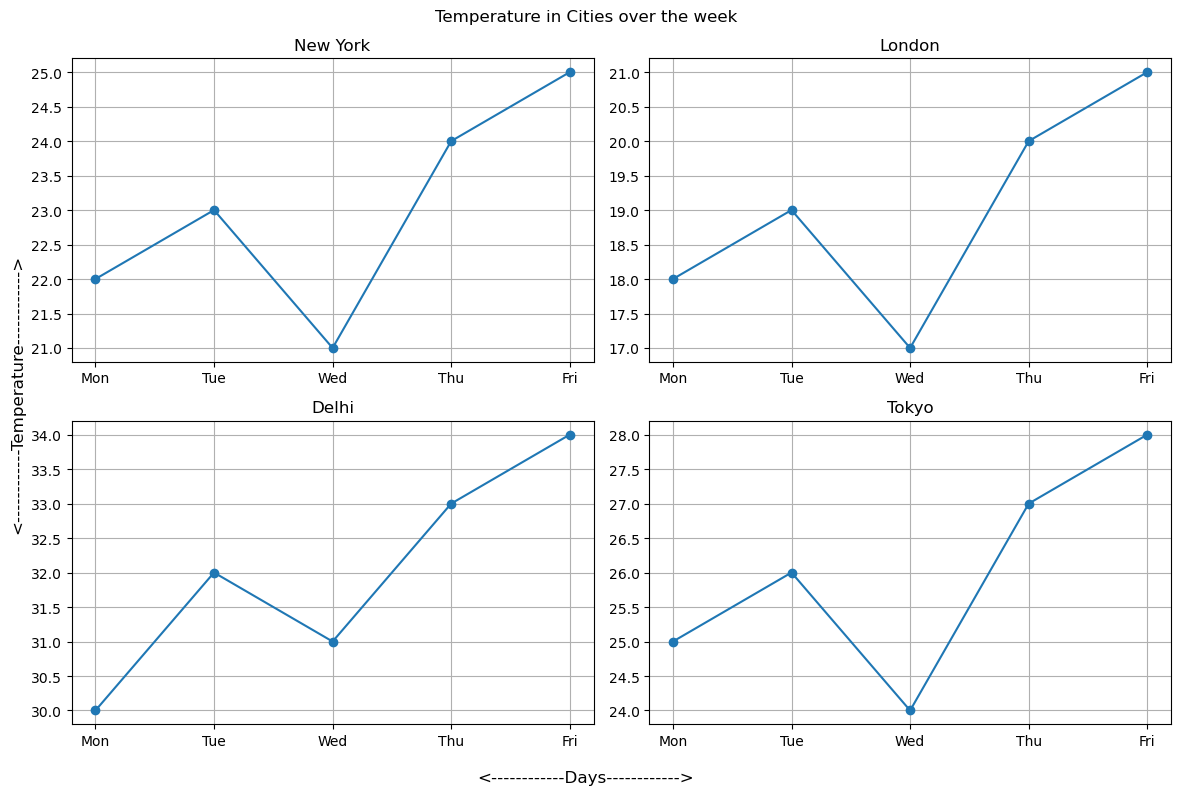

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(days, temperatures[0], marker = 'o')  
axs[0, 0].set_title("New York")
axs[0, 0].grid(True)

axs[0, 1].plot(days, temperatures[1], marker = 'o')  
axs[0, 1].set_title("London")  

axs[1, 0].plot(days, temperatures[2], marker = 'o')  
axs[1, 0].set_title("Delhi")  

axs[1, 1].plot(days, temperatures[3], marker = 'o')  
axs[1, 1].set_title("Tokyo")  

for ax in axs.flat:
    ax.grid(True)

fig.suptitle("Temperature in Cities over the week")
fig.supxlabel("<------------Days------------>")
fig.supylabel("<------------Temperature------------>")

plt.tight_layout()  
plt.show()

In [35]:
fig.savefig("Weekly Temperature.png")

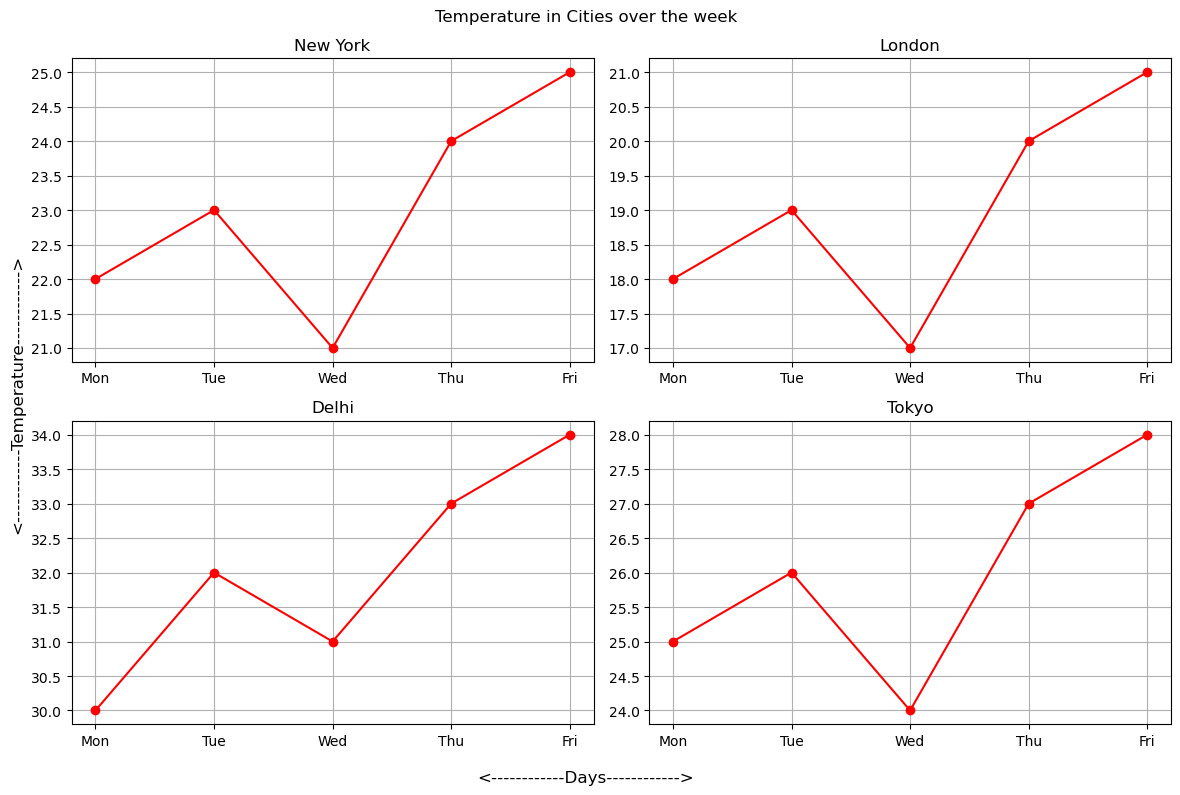

In [33]:
# Solution Using Flatten
fig, axes = plt.subplots(2,2, figsize=(12, 8))

axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.plot(days, temperatures[i], marker='o', color = 'red')
    ax.set_title(cities[i])
    ax.grid(True)

fig.suptitle("Temperature in Cities over the week")
fig.supxlabel("<------------Days------------>")
fig.supylabel("<------------Temperature------------>")

plt.tight_layout()  
plt.show()


In [34]:
fig.savefig("Weekly Temperature Flatten.png")

# Assignment (Data Visualization)

## Question 1: 

For the following dataset generated using NumPy:

    np.random.normal(loc=70, scale=10, size=200)
    Plot a histogram of the scores.
    Draw a vertical line for the mean and try to interpret the results.

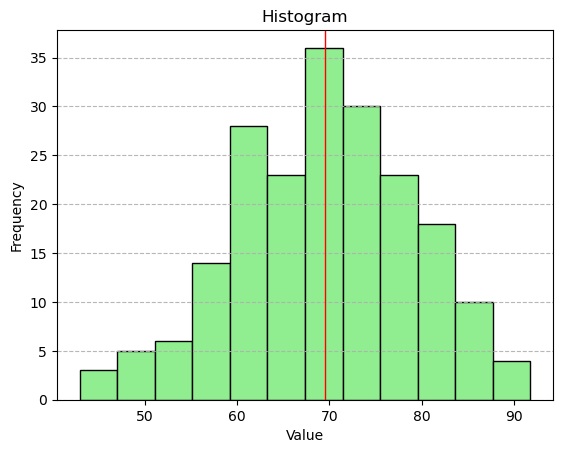

In [33]:
data = np.random.normal(loc=70, scale=10, size=200)

plt.hist(data, bins=12, color='lightgreen', edgecolor='black')

mean_value = np.mean(data)
plt.axvline(mean_value, color='red', linewidth=1, label=f"Mean = {mean_value:.2f}")

plt.xlabel("Value")  
plt.ylabel("Frequency")  
plt.title("Histogram")  
plt.grid(axis='y', linestyle='--', alpha=.9)  

plt.show()

## Question 2:

For Seaborn Penguins Dataset:

    Plot flipper_length_mm vs body_mass_g
    Color by species

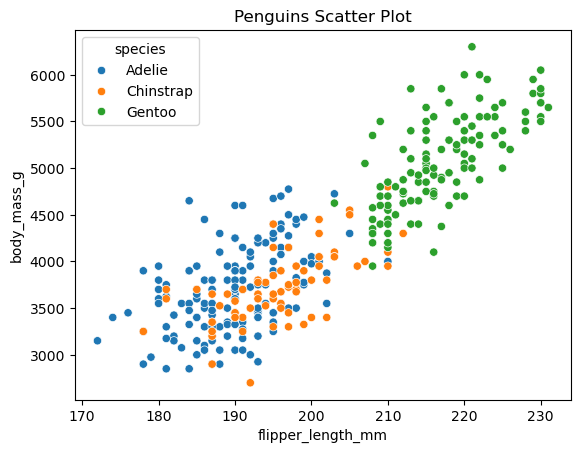

In [42]:
penguins = sns.load_dataset("penguins") 

sns.scatterplot(data = penguins, x = "flipper_length_mm" , y = "body_mass_g" , hue = "species")

plt.title("Penguins Scatter Plot")  
plt.show()

## Question 3:

From the Seaborn Tips dataset:

    Create a box plot for total_bill vs day.
    Add hue="sex" to differentiate by gender.
    Identify which day has the highest median bill.
    Comment on any outliers.

In [4]:
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


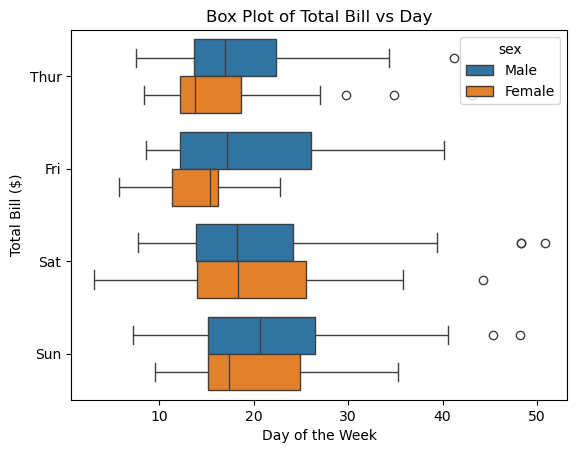

In [6]:
sns.boxplot(data=tips, x="total_bill", y="day", hue="sex")  

plt.ylabel("Total Bill ($)")
plt.xlabel("Day of the Week")
plt.title("Box Plot of Total Bill vs Day")  
plt.show() 

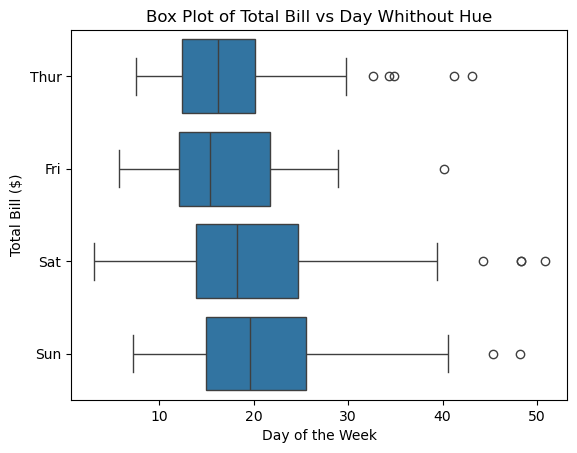

In [10]:
sns.boxplot(data=tips, x="total_bill", y="day")  

plt.ylabel("Total Bill ($)")
plt.xlabel("Day of the Week")
plt.title("Box Plot of Total Bill vs Day Whithout Hue")  
plt.show() 

Analysis:
Median: Sunday has the highest median value (19.63)

Outliers: There are some high paid tips (outside the whiskers) in Saturday and Sunday. In Saturday the tips went above 50$ which were paid by Male customers.
          No outliers in Friday.

In [8]:
print(tips.groupby("day")["total_bill"].median())

day
Thur    16.20
Fri     15.38
Sat     18.24
Sun     19.63
Name: total_bill, dtype: float64


C:\Users\akibz\AppData\Local\Temp\ipykernel_41844\2406886611.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby("day")["total_bill"].median())


## Question 4:

For the Seaborn tips dataset, do the following:

    Create a scatter plot of total_bill vs tip
    Color points by sex
    Use different markers for smoker
    Add a title and axis labels
    Analyze: Do smokers tend to tip differently?

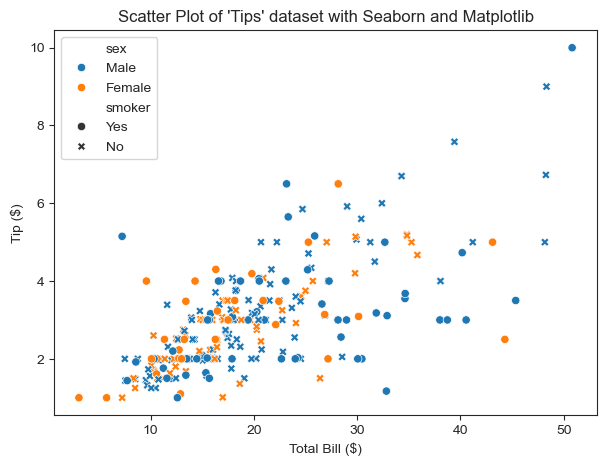

In [29]:
tips = sns.load_dataset("tips")

fig, ax = plt.subplots(figsize=(7,5)) 

sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",         
    style="smoker",     
    markers={"Yes": "o", "No": "X"},          
    ax=ax
)
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Scatter Plot of 'Tips' dataset with Seaborn and Matplotlib")  
plt.show()

Analysis: 
    From the plot we can say that there was no special behaviour found among the smokers while giving tips.
    Both the smokers and non-smokers tend to give more tips as the total bill rises.

## Question 5:

For the Seaborn tips dataset, do the following:

    Create a pivot table of average tip
    Rows: day
    Columns: time
    Plot the pivot table as a heatmap
    Annotate values
    Interpret which day–time combination performs best

In [30]:
tips = sns.load_dataset("tips")

In [33]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [34]:
tips_pivot = tips.pivot_table(
    index="day",
    columns="time",
    values="tip",
    aggfunc="mean"
)
print(tips_pivot)

C:\Users\akibz\AppData\Local\Temp\ipykernel_41844\3519937670.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips_pivot = tips.pivot_table(


time     Lunch    Dinner
day                     
Thur  2.767705  3.000000
Fri   2.382857  2.940000
Sat        NaN  2.993103
Sun        NaN  3.255132


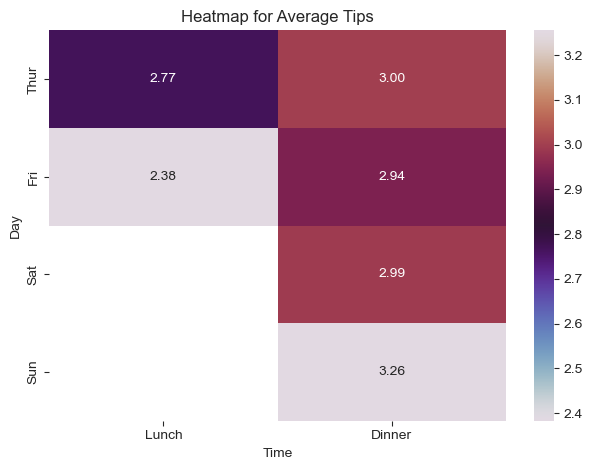

In [44]:
sns.heatmap(
    tips_pivot,
    cmap="twilight", annot=True, fmt=".2f"
)
plt.xlabel("Time")
plt.ylabel("Day")
plt.title("Heatmap for Average Tips")
plt.tight_layout()
plt.show()